In [32]:
#import statements
import os
import copy
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
import nilearn
import nilearn.image
import nilearn.plotting
import ants
import nilearn.image as nli
import nilearn.plotting as nlp
import pydicom
import pyarrow.parquet as pq

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchinfo import summary

from sklearn.decomposition import PCA
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc,
)
from sklearn.model_selection import (
    StratifiedGroupKFold, cross_validate, train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize, MinMaxScaler, StandardScaler
from sklearn.svm import SVC

In [24]:
DATA     = Path("model_data/adni")
T1_LONG  = DATA / "t1_long_data"
DTI_LONG = DATA / "dti_long_data"

meta = pd.read_csv(DATA / "paired_df_long_v2.csv")
MODALITIES = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]

print(f"Cohort: {len(meta)} paired subjects")
print("group:  ", meta["group"].value_counts().to_dict())
print("amyloid:", meta["amyloid_label"].value_counts(dropna=False).to_dict())

Cohort: 786 paired subjects
group:   {'CN': 411, 'MCI': 282, 'Dementia': 77}
amyloid: {0.0: 387, 1.0: 336, nan: 63}


In [4]:
key_col = {
    "t1_gm":  "t1_image_subject_id",
    "t1_wm":  "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm": "dti_image_subject_id",
    "dti_wm": "dti_image_subject_id",
    "dti_csf":"dti_image_subject_id",
}
parquet_paths = {
    "t1_gm":  T1_LONG  / "t1_long_masked_gm.parquet",
    "t1_wm":  T1_LONG  / "t1_long_masked_wm.parquet",
    "t1_csf": T1_LONG  / "t1_long_masked_csf.parquet",
    "dti_gm": DTI_LONG / "dti_long_masked_gm_md.parquet",
    "dti_wm": DTI_LONG / "dti_long_masked_wm_md.parquet",
    "dti_csf":DTI_LONG / "dti_long_masked_csf_md.parquet",
}

# Parquets can exceed pyarrow's default thrift limit (~1 GB metadata) — raise it.
def _read_parquet(path):
    return pq.read_pandas(str(path),
                          thrift_string_size_limit=2_000_000_000,
                          thrift_container_size_limit=2_000_000_000).to_pandas()

X_raw = {}
for k, p in parquet_paths.items():
    df = _read_parquet(p)
    X_raw[k] = df.loc[meta[key_col[k]]].values.astype(np.float32)
    print(f"  {k}: {X_raw[k].shape}")

  t1_gm: (786, 831863)
  t1_wm: (786, 785285)
  t1_csf: (786, 337620)
  dti_gm: (786, 831863)
  dti_wm: (786, 785285)
  dti_csf: (786, 337620)


In [17]:
# 2-class: CN vs MCI+Dementia (all 770 subjects with valid diagnosis)
bin_mask   = meta["group"].notna().values          # drops 16 rows with no DXSUM within 180d

y_bin      = meta.loc[bin_mask, "group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
idx_bin    = np.where(bin_mask)[0]
groups_bin = meta.loc[bin_mask, "subject_id"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
local_tr, local_te = next(sgkf.split(np.arange(len(y_bin)), y_bin, groups_bin))
y_bin_tr, y_bin_te = y_bin[local_tr], y_bin[local_te]

assert len(set(groups_bin[local_tr]) & set(groups_bin[local_te])) == 0, "Subject leakage!"

print(f"2-class split: total={len(y_bin)}  train={len(local_tr)}  test={len(local_te)}")
print(f"  CN:           {(y_bin == 0).sum()}")
print(f"  MCI+Dementia: {(y_bin == 1).sum()}")

2-class split: total=770  train=602  test=168
  CN:           411
  MCI+Dementia: 359


In [7]:
cn_mask  = meta["group"].eq("CN").values
PC_RANGE = list(range(1, 51))
scalers  = {}
scree_records, bacc_records = [], []

# CN vs Dementia subset for the scree/bAcc sweep
cd_mask   = meta["group"].isin(["CN", "Dementia"]).values
y_cd      = meta.loc[cd_mask, "group"].map({"CN": 0, "Dementia": 1}).values.astype(np.int64)
idx_cd    = np.where(cd_mask)[0]
groups_cd = meta.loc[cd_mask, "subject_id"].values

sgkf_cd = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
cd_tr, cd_te = next(sgkf_cd.split(np.arange(len(y_cd)), y_cd, groups_cd))
y_cd_tr, y_cd_te = y_cd[cd_tr], y_cd[cd_te]

for mod in MODALITIES:
    X_mod  = X_raw[mod].astype(np.float32)
    scaler = StandardScaler().fit(X_mod[cn_mask])
    scalers[mod] = scaler

    X_full = scaler.transform(X_mod)
    Xb     = X_full[idx_cd]
    Xb_tr  = Xb[cd_tr]
    Xb_te  = Xb[cd_te]

    pca = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(Xb_tr)
    evr = pca.explained_variance_ratio_
    Z_tr = pca.transform(Xb_tr)
    Z_te = pca.transform(Xb_te)

    for n_pc in PC_RANGE:
        scree_records.append({"modality": mod, "n_pc": n_pc, "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0).fit(Z_tr[:, :n_pc], y_cd_tr)
        bacc = balanced_accuracy_score(y_cd_te, clf.predict(Z_te[:, :n_pc]))
        bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

scree_df = pd.DataFrame(scree_records)
bacc_df  = pd.DataFrame(bacc_records)

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


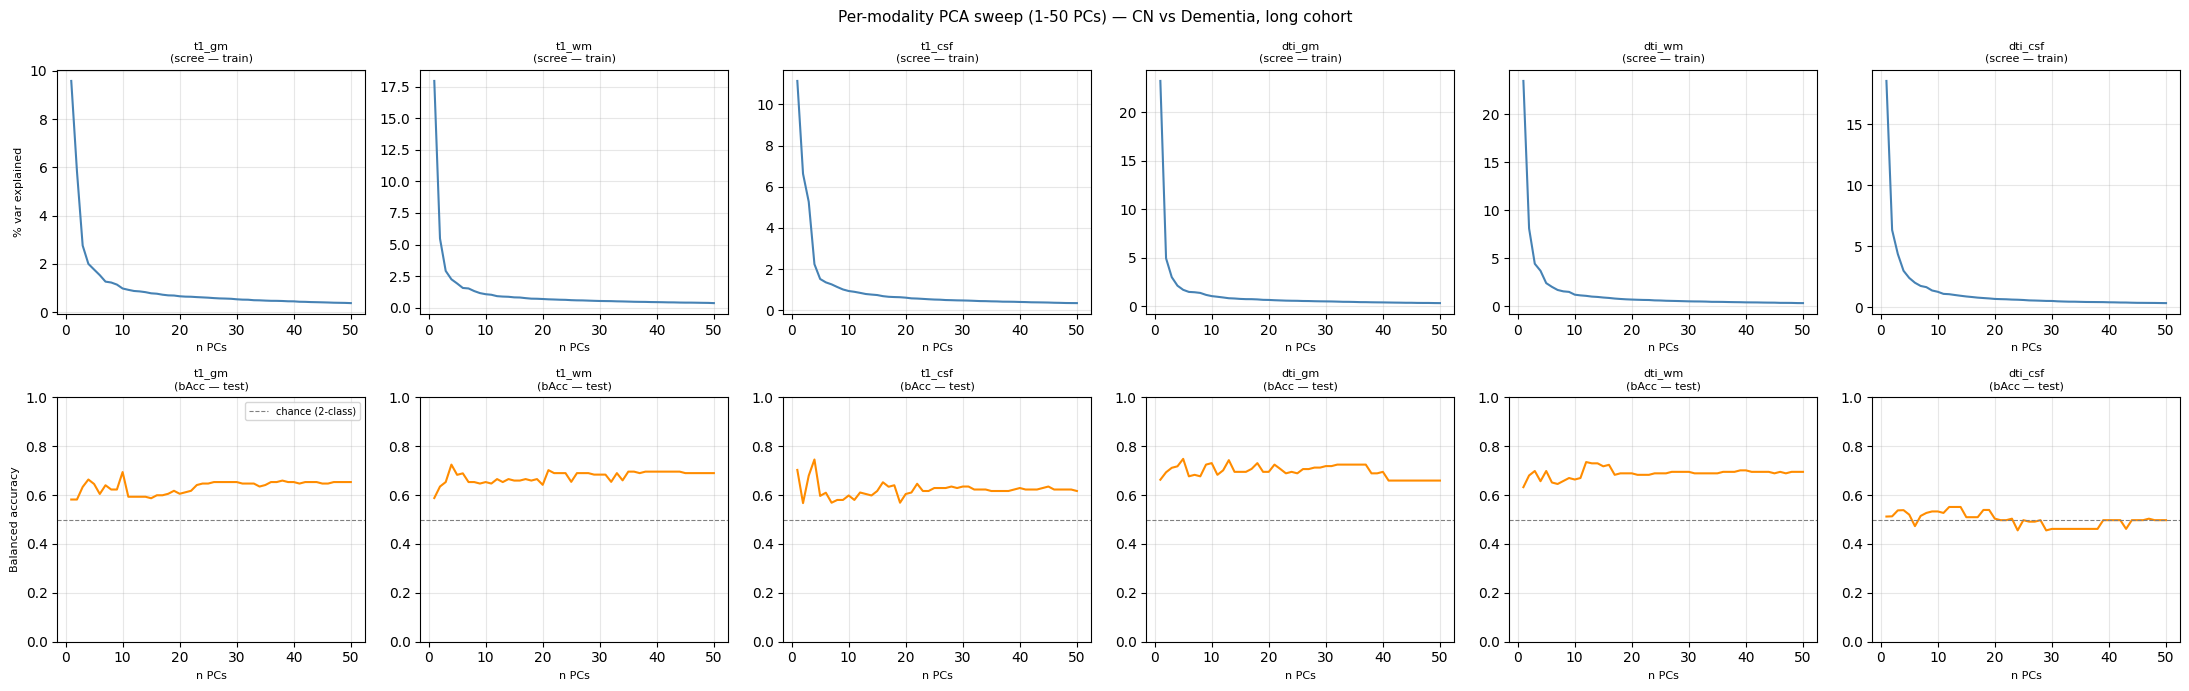

In [19]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = scree_df[scree_df["modality"] == mod]
    sub_b = bacc_df[bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.5, color="grey", lw=0.8, ls="--", label="chance (2-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1-50 PCs) — CN vs Dementia, long cohort",
    fontsize=11,
)
plt.tight_layout()
plt.show()


In [ ]:
N_PC = 15
tasks = {
    "CN vs Dementia":     meta["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": meta["group"].notna(),
}

print(f"{'Task':<22}  {'bAcc mean':>10}  {'bAcc std':>9}  {'n_test_min':>10}")
print("-" * 56)

for task_name, mask in tasks.items():
    sub  = meta[mask].reset_index(drop=True)
    y_t  = sub["group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
    grp  = sub["subject_id"].values
    idx  = np.where(mask.values)[0]
    Xs   = scalers["t1_gm"].transform(X_raw["t1_gm"].astype(np.float32))[idx]

    sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
    baccs = []
    fold_test_sizes = []
    for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp):
        pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs[tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(pca.transform(Xs[tr]), y_t[tr])
        baccs.append(balanced_accuracy_score(y_t[te], clf.predict(pca.transform(Xs[te]))))
        fold_test_sizes.append((y_t[te] == 1).sum())  # minority class in test

    print(f"{task_name:<22}  {np.mean(baccs):>10.3f}  {np.std(baccs):>9.3f}  {min(fold_test_sizes):>10}")

Task                     bAcc mean   bAcc std  n_test_min
--------------------------------------------------------
CN vs Dementia               0.750      0.108          10
CN vs MCI                    0.640      0.042          39
CN vs MCI+Dementia           0.689      0.043          58


In [15]:
# --- 5-fold CV restricted to Siemens DTI subjects ----------------------------
N_PC = 15

scanner_df = pd.read_csv("model_data/adni/scanner_info_long.csv")
meta_sc = meta.merge(
    scanner_df,
    left_on=["subject_id", "t1_image_subject_id", "dti_image_subject_id"],
    right_on=["subject_id", "t1_id", "dti_id"],
    how="left"
)
meta_sc["dti_mfr"] = meta_sc["dti_scanner"].str.split("_").str[0]

# Boolean mask into meta/X_raw rows: Siemens DTI + valid diagnosis
siemens_mask = (meta_sc["dti_mfr"] == "Siemens") & meta_sc["group"].notna()
siemens_idx  = np.where(siemens_mask.values)[0]
meta_sc_s    = meta_sc[siemens_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_s["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_s["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_s)),
}

print(f"Siemens DTI subset: {len(meta_sc_s)} rows | "
      f"CN={( meta_sc_s['group']=='CN').sum()} "
      f"MCI={(meta_sc_s['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_s['group']=='Dementia').sum()}")
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {'±':>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_s    = Xs_full[siemens_idx]          # rows for Siemens subjects only

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_s[sub_idx]
        y_t     = meta_sc_s.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_s.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()

Siemens DTI subset: 667 rows | CN=363 MCI=232 Dementia=72

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.778  0.039      9
t1_gm           CN vs MCI                0.671  0.050     28
t1_gm           CN vs MCI+Dementia       0.695  0.060     50

t1_wm           CN vs Dementia           0.693  0.059      9
t1_wm           CN vs MCI                0.631  0.039     28
t1_wm           CN vs MCI+Dementia       0.675  0.069     50

t1_csf          CN vs Dementia           0.667  0.063      9
t1_csf          CN vs MCI                0.622  0.048     28
t1_csf          CN vs MCI+Dementia       0.639  0.062     50

dti_gm          CN vs Dementia           0.772  0.068      9
dti_gm          CN vs MCI                0.633  0.033     28
dti_gm          CN vs MCI+Dementia       0.693  0.044     50

dti_wm          CN vs Dementia           0.823  0.055      9
dti_wm          CN vs 

In [20]:
# --- 5-fold CV restricted to Siemens + GE DTI subjects -----------------------
# Requires meta_sc / scalers from cells above
N_PC = 15

sg_mask  = (meta_sc["dti_mfr"].isin(["Siemens", "GE"])) & meta_sc["group"].notna()
sg_idx   = np.where(sg_mask.values)[0]
meta_sc_sg = meta_sc[sg_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_sg["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_sg["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_sg)),
}

print(f"Siemens+GE DTI subset: {len(meta_sc_sg)} rows | "
      f"CN={(meta_sc_sg['group']=='CN').sum()} "
      f"MCI={(meta_sc_sg['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_sg['group']=='Dementia').sum()}")
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {'\xb1':>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_sg   = Xs_full[sg_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_sg[sub_idx]
        y_t     = meta_sc_sg.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_sg.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Siemens+GE DTI subset: 725 rows | CN=383 MCI=267 Dementia=75

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.779  0.120      8
t1_gm           CN vs MCI                0.637  0.035     38
t1_gm           CN vs MCI+Dementia       0.679  0.020     58

t1_wm           CN vs Dementia           0.639  0.106      8
t1_wm           CN vs MCI                0.621  0.025     38
t1_wm           CN vs MCI+Dementia       0.670  0.022     58

t1_csf          CN vs Dementia           0.705  0.061      8
t1_csf          CN vs MCI                0.615  0.054     38
t1_csf          CN vs MCI+Dementia       0.640  0.043     58

dti_gm          CN vs Dementia           0.738  0.111      8
dti_gm          CN vs MCI                0.637  0.058     38
dti_gm          CN vs MCI+Dementia       0.674  0.028     58

dti_wm          CN vs Dementia           0.766  0.080      8
dti_wm          CN 

In [21]:
# --- 5-fold CV restricted to Siemens + Philips DTI subjects ------------------
# Requires meta_sc / scalers from cells above
N_PC = 15

sp_mask  = (meta_sc["dti_mfr"].isin(["Siemens", "Philips"])) & meta_sc["group"].notna()
sp_idx   = np.where(sp_mask.values)[0]
meta_sc_sp = meta_sc[sp_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_sp["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_sp["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_sp)),
}

print(f"Siemens+Philips DTI subset: {len(meta_sc_sp)} rows | "
      f"CN={(meta_sc_sp['group']=='CN').sum()} "
      f"MCI={(meta_sc_sp['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_sp['group']=='Dementia').sum()}")
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {'\xb1':>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_sp   = Xs_full[sp_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_sp[sub_idx]
        y_t     = meta_sc_sp.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_sp.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Siemens+Philips DTI subset: 712 rows | CN=391 MCI=247 Dementia=74

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.753  0.094     11
t1_gm           CN vs MCI                0.667  0.080     45
t1_gm           CN vs MCI+Dementia       0.696  0.022     50

t1_wm           CN vs Dementia           0.666  0.067     11
t1_wm           CN vs MCI                0.628  0.027     45
t1_wm           CN vs MCI+Dementia       0.653  0.041     50

t1_csf          CN vs Dementia           0.693  0.060     11
t1_csf          CN vs MCI                0.607  0.037     45
t1_csf          CN vs MCI+Dementia       0.644  0.040     50

dti_gm          CN vs Dementia           0.742  0.084     11
dti_gm          CN vs MCI                0.632  0.058     45
dti_gm          CN vs MCI+Dementia       0.672  0.048     50

dti_wm          CN vs Dementia           0.826  0.062     11
dti_wm        

In [22]:
# --- 5-fold CV all DTI manufacturers (Siemens + GE + Philips) ----------------
# Requires meta_sc / scalers from cells above
N_PC = 15

all_mask  = meta_sc["group"].notna()
all_idx   = np.where(all_mask.values)[0]
meta_sc_all = meta_sc[all_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_all["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_all["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_all)),
}

print(f"All manufacturers subset: {len(meta_sc_all)} rows | "
      f"CN={(meta_sc_all['group']=='CN').sum()} "
      f"MCI={(meta_sc_all['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_all['group']=='Dementia').sum()}")
mfr_counts = meta_sc_all["dti_mfr"].value_counts()
print("DTI manufacturer breakdown:", mfr_counts.to_dict())
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {chr(177):>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full  = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_all   = Xs_full[all_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_all[sub_idx]
        y_t     = meta_sc_all.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_all.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


All manufacturers subset: 770 rows | CN=411 MCI=282 Dementia=77
DTI manufacturer breakdown: {'Siemens': 667, 'GE': 58, 'Philips': 45}

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.750  0.108     10
t1_gm           CN vs MCI                0.640  0.042     39
t1_gm           CN vs MCI+Dementia       0.689  0.043     58

t1_wm           CN vs Dementia           0.672  0.045     10
t1_wm           CN vs MCI                0.622  0.047     39
t1_wm           CN vs MCI+Dementia       0.664  0.043     58

t1_csf          CN vs Dementia           0.671  0.078     10
t1_csf          CN vs MCI                0.586  0.029     39
t1_csf          CN vs MCI+Dementia       0.649  0.026     58

dti_gm          CN vs Dementia           0.762  0.060     10
dti_gm          CN vs MCI                0.627  0.039     39
dti_gm          CN vs MCI+Dementia       0.658  0.020     58

dti_wm 

In [18]:
# --- Multimodal score fusion 5-fold CV, all manufacturers -------------------
# Score fusion: per-modality PCA+SVM decision functions averaged, then thresholded.
# Reuses meta_sc_all, all_idx, scalers from cells above.
N_PC = 15

FUSION_GROUPS = {
    "t1_gm + dti_wm":  ["t1_gm", "dti_wm"],
    "all T1":           ["t1_gm", "t1_wm", "t1_csf"],
    "all DTI":          ["dti_gm", "dti_wm", "dti_csf"],
    "all 6 modalities": ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"],
}

fusion_tasks = {
    "CN vs Dementia":     meta_sc_all["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_all["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_all)),
}

header = f"{'Fusion':<20}  {'Task':<22}  {'bAcc':>6}  {chr(177):>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for fusion_name, mods in FUSION_GROUPS.items():
    for task_name, task_mask in fusion_tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        y_t   = meta_sc_all.loc[task_mask, "group"].map(
                    {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t = meta_sc_all.loc[task_mask, "subject_id"].values

        # Pre-scale and subset features for each modality
        Xs_by_mod = {
            mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[all_idx][sub_idx]
            for mod in mods
        }

        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            fold_scores = np.zeros(len(te))
            for mod in mods:
                Xs_t = Xs_by_mod[mod]
                pca  = PCA(n_components=N_PC, random_state=0,
                           svd_solver="randomized").fit(Xs_t[tr])
                clf  = SVC(class_weight="balanced", random_state=0).fit(
                           pca.transform(Xs_t[tr]), y_t[tr])
                fold_scores += clf.decision_function(pca.transform(Xs_t[te]))
            y_pred = (fold_scores > 0).astype(int)
            baccs.append(balanced_accuracy_score(y_t[te], y_pred))
            mins.append((y_t[te] == 1).sum())

        print(f"{fusion_name:<20}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Fusion                Task                      bAcc      ±  n_min
------------------------------------------------------------------
t1_gm + dti_wm        CN vs Dementia           0.802  0.063     10
t1_gm + dti_wm        CN vs MCI                0.649  0.041     39
t1_gm + dti_wm        CN vs MCI+Dementia       0.696  0.037     58

all T1                CN vs Dementia           0.726  0.086     10
all T1                CN vs MCI                0.631  0.043     39
all T1                CN vs MCI+Dementia       0.683  0.053     58

all DTI               CN vs Dementia           0.752  0.076     10
all DTI               CN vs MCI                0.628  0.051     39
all DTI               CN vs MCI+Dementia       0.658  0.035     58

all 6 modalities      CN vs Dementia           0.755  0.070     10
all 6 modalities      CN vs MCI                0.631  0.052     39
all 6 modalities      CN vs MCI+Dementia       0.684  0.033     58



In [22]:
# --- Multimodal score fusion 5-fold CV, Siemens only ------------------------
# Reuses meta_sc_s, siemens_idx, scalers from cells above.
N_PC = 15

fusion_tasks_s = {
    "CN vs Dementia":     meta_sc_s["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_s["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_s)),
}

header = f"{'Fusion':<20}  {'Task':<22}  {'bAcc':>6}  {chr(177):>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for fusion_name, mods in FUSION_GROUPS.items():
    for task_name, task_mask in fusion_tasks_s.items():
        sub_idx = np.where(task_mask.values)[0]
        y_t   = meta_sc_s.loc[task_mask, "group"].map(
                    {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t = meta_sc_s.loc[task_mask, "subject_id"].values

        Xs_by_mod = {
            mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[siemens_idx][sub_idx]
            for mod in mods
        }

        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            fold_scores = np.zeros(len(te))
            for mod in mods:
                Xs_t = Xs_by_mod[mod]
                pca  = PCA(n_components=N_PC, random_state=0,
                           svd_solver="randomized").fit(Xs_t[tr])
                clf  = SVC(class_weight="balanced", random_state=0).fit(
                           pca.transform(Xs_t[tr]), y_t[tr])
                fold_scores += clf.decision_function(pca.transform(Xs_t[te]))
            y_pred = (fold_scores > 0).astype(int)
            baccs.append(balanced_accuracy_score(y_t[te], y_pred))
            mins.append((y_t[te] == 1).sum())

        print(f"{fusion_name:<20}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Fusion                Task                      bAcc      ±  n_min
------------------------------------------------------------------
t1_gm + dti_wm        CN vs Dementia           0.824  0.046      9
t1_gm + dti_wm        CN vs MCI                0.668  0.040     28
t1_gm + dti_wm        CN vs MCI+Dementia       0.712  0.048     50

all T1                CN vs Dementia           0.755  0.076      9
all T1                CN vs MCI                0.668  0.022     28
all T1                CN vs MCI+Dementia       0.689  0.067     50

all DTI               CN vs Dementia           0.754  0.081      9
all DTI               CN vs MCI                0.649  0.031     28
all DTI               CN vs MCI+Dementia       0.692  0.054     50

all 6 modalities      CN vs Dementia           0.777  0.048      9
all 6 modalities      CN vs MCI                0.661  0.033     28
all 6 modalities      CN vs MCI+Dementia       0.687  0.045     50



In [8]:
# --- Amyloid +/- scree plot (all subjects with valid amyloid label) -----------
# Stage 2 of two-stage pipeline: after CN vs AD, classify amyloid +/-
amy_mask   = meta["amyloid_label"].notna().values
y_amy      = meta.loc[amy_mask, "amyloid_label"].astype(int).values   # 0=amy-, 1=amy+
idx_amy    = np.where(amy_mask)[0]
groups_amy = meta.loc[amy_mask, "subject_id"].values

print(f"Amyloid subset: {amy_mask.sum()} subjects | "
      f"amy-={(y_amy==0).sum()}  amy+={(y_amy==1).sum()}")

sgkf_amy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
amy_tr, amy_te = next(sgkf_amy.split(np.arange(len(y_amy)), y_amy, groups_amy))
y_amy_tr, y_amy_te = y_amy[amy_tr], y_amy[amy_te]

print(f"Train: amy-={(y_amy_tr==0).sum()}  amy+={(y_amy_tr==1).sum()}")
print(f"Test:  amy-={(y_amy_te==0).sum()}  amy+={(y_amy_te==1).sum()}")
print()

amy_scree_records, amy_bacc_records = [], []

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xb      = Xs_full[idx_amy]
    Xb_tr   = Xb[amy_tr]
    Xb_te   = Xb[amy_te]

    pca = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(Xb_tr)
    evr = pca.explained_variance_ratio_
    Z_tr = pca.transform(Xb_tr)
    Z_te = pca.transform(Xb_te)

    for n_pc in range(1, 51):
        amy_scree_records.append({"modality": mod, "n_pc": n_pc,
                                   "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0).fit(Z_tr[:, :n_pc], y_amy_tr)
        bacc = balanced_accuracy_score(y_amy_te, clf.predict(Z_te[:, :n_pc]))
        amy_bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

amy_scree_df = pd.DataFrame(amy_scree_records)
amy_bacc_df  = pd.DataFrame(amy_bacc_records)

Amyloid subset: 723 subjects | amy-=387  amy+=336
Train: amy-=302  amy+=270
Test:  amy-=85  amy+=66

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


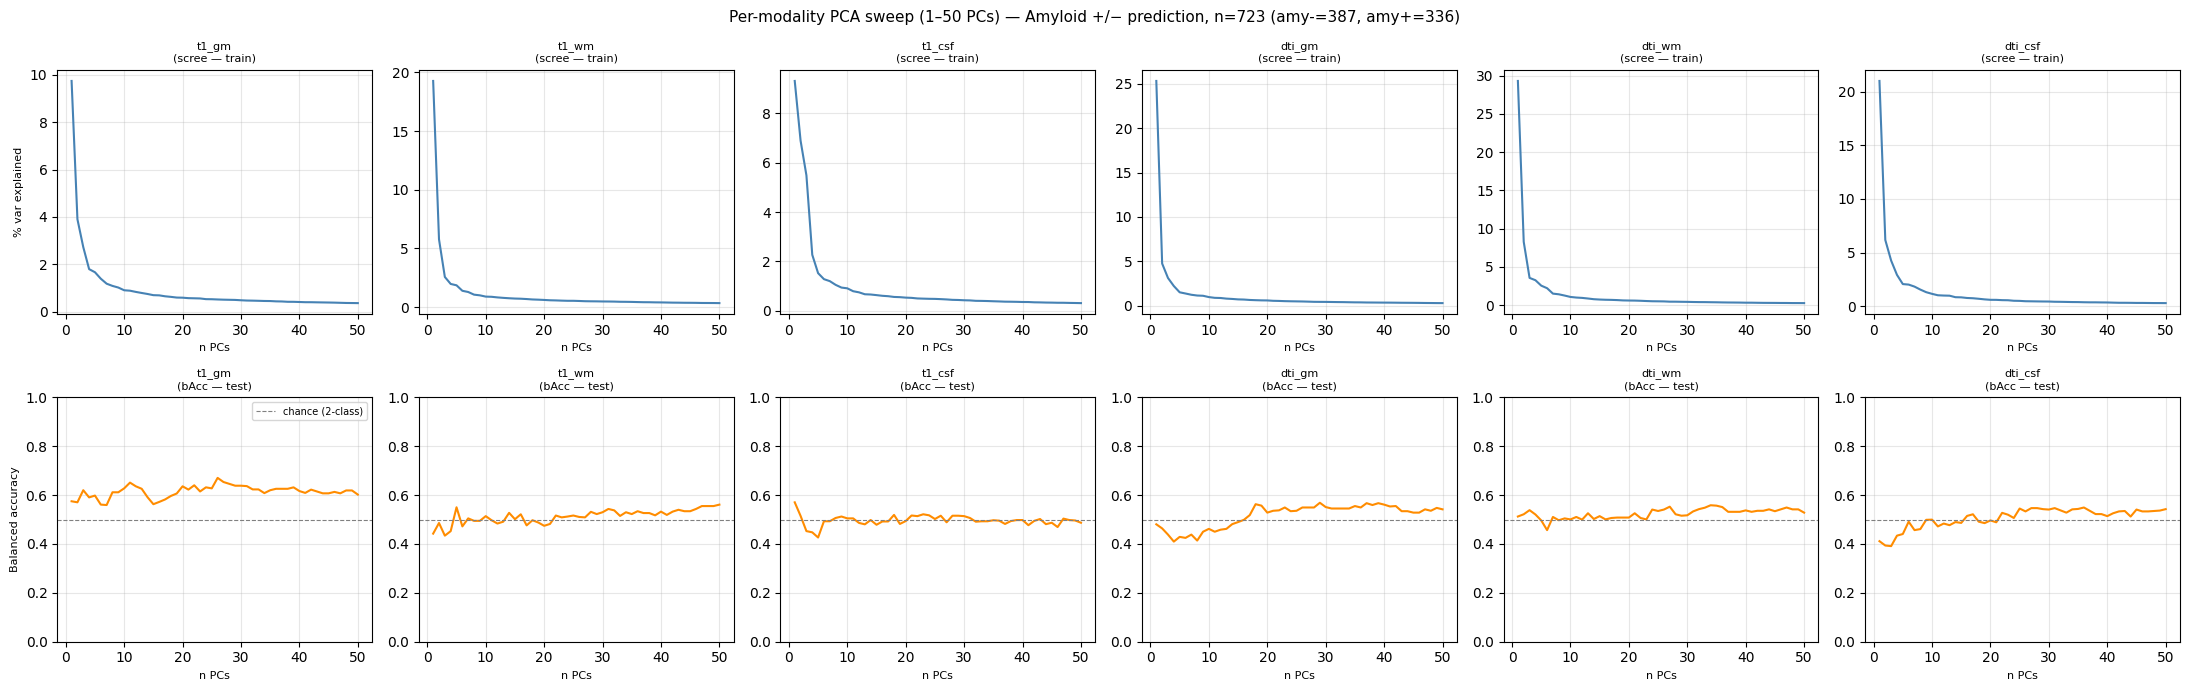

In [9]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = amy_scree_df[amy_scree_df["modality"] == mod]
    sub_b = amy_bacc_df[amy_bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.5, color="grey", lw=0.8, ls="--", label="chance (2-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1–50 PCs) — Amyloid +/− prediction, "
    f"n={amy_mask.sum()} (amy-={(y_amy==0).sum()}, amy+={(y_amy==1).sum()})",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [14]:
# --- Amyloid +/- 5-fold CV, all manufacturers, all modalities ----------------
# Requires meta_sc / scalers from cells above
N_PC = 15

# All manufacturers + valid amyloid label
amy_all_mask   = meta_sc["amyloid_label"].notna()
amy_all_idx    = np.where(amy_all_mask.values)[0]
meta_sc_amy_all = meta_sc[amy_all_mask].reset_index(drop=True)

y_amy_all     = meta_sc_amy_all["amyloid_label"].astype(int).values   # 0=amy-, 1=amy+
groups_amy_all = meta_sc_amy_all["subject_id"].values

mfr_counts = meta_sc_amy_all["dti_mfr"].value_counts()
print(f"All-manufacturer amyloid subset: {len(meta_sc_amy_all)} subjects | "
      f"amy-={(y_amy_all==0).sum()}  amy+={(y_amy_all==1).sum()}")
print("DTI manufacturer breakdown:", mfr_counts.to_dict())
print()

amy_all_records = []

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

for mod in MODALITIES:
    Xs_full    = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_amy_all = Xs_full[amy_all_idx]

    baccs, senss, specs = [], [], []
    for tr, te in sgkf.split(np.arange(len(y_amy_all)), y_amy_all, groups_amy_all):
        pca = PCA(n_components=N_PC, random_state=0,
                  svd_solver="randomized").fit(Xs_amy_all[tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(
                  pca.transform(Xs_amy_all[tr]), y_amy_all[tr])
        y_pred = clf.predict(pca.transform(Xs_amy_all[te]))
        bacc   = balanced_accuracy_score(y_amy_all[te], y_pred)
        tn, fp, fn, tp = confusion_matrix(
                  y_amy_all[te], y_pred, labels=[0, 1]).ravel()
        baccs.append(bacc)
        senss.append(tp / (tp + fn) if (tp + fn) else float("nan"))
        specs.append(tn / (tn + fp) if (tn + fp) else float("nan"))

    amy_all_records.append({
        "modality":   mod,
        "bAcc_mean":  float(np.mean(baccs)),
        "bAcc_std":   float(np.std(baccs)),
        "sens_mean":  float(np.nanmean(senss)),
        "spec_mean":  float(np.nanmean(specs)),
        "n_test_min": int(min((y_amy_all[te] == 1).sum()
                              for _, te in sgkf.split(
                                  np.arange(len(y_amy_all)),
                                  y_amy_all, groups_amy_all))),
    })
    print(f"  {mod} done")

amy_all_df = pd.DataFrame(amy_all_records)


All-manufacturer amyloid subset: 723 subjects | amy-=387  amy+=336
DTI manufacturer breakdown: {'Siemens': 617, 'GE': 59, 'Philips': 47}

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


In [15]:
# --- Display amyloid +/- 5-fold CV results (all manufacturers) ---------------
print(f"Amyloid +/- classification — all manufacturers, N_PC={N_PC}, 5-fold CV")
print(f"n={len(meta_sc_amy_all)}  amy-={(y_amy_all==0).sum()}  amy+={(y_amy_all==1).sum()}")
print()

header = (f"{'Modality':<14}  {'bAcc':>6}  {chr(177):>5}  "
          f"{'Sens+':>6}  {'Spec-':>6}  {'n_min':>5}")
print(header)
print("-" * len(header))

for _, row in amy_all_df.iterrows():
    print(f"{row['modality']:<14}  "
          f"{row['bAcc_mean']:>6.3f}  {row['bAcc_std']:>5.3f}  "
          f"{row['sens_mean']:>6.3f}  {row['spec_mean']:>6.3f}  "
          f"{row['n_test_min']:>5}")


Amyloid +/- classification — all manufacturers, N_PC=15, 5-fold CV
n=723  amy-=387  amy+=336

Modality          bAcc      ±   Sens+   Spec-  n_min
----------------------------------------------------
t1_gm            0.553  0.073   0.615   0.491     57
t1_wm            0.518  0.017   0.507   0.529     57
t1_csf           0.501  0.050   0.524   0.479     57
dti_gm           0.540  0.032   0.628   0.453     57
dti_wm           0.525  0.026   0.498   0.553     57
dti_csf          0.497  0.035   0.553   0.440     57


In [26]:
# --- Two-stage parallel pipeline: CN vs Dementia + Amyloid +/-, Siemens only ---
N_PC        = 15
FUSION_MODS = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]
sgkf        = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

# ── Stage 1: CN vs Dementia (Siemens) ────────────────────────────────────────
stage1_mask = meta_sc_s["group"].isin(["CN", "Dementia"])
meta_s1     = meta_sc_s[stage1_mask].reset_index(drop=True)
s1_local    = np.where(stage1_mask.values)[0]        # indices into meta_sc_s

y_s1   = meta_s1["group"].map({"CN": 0, "Dementia": 1}).values.astype(np.int64)
grp_s1 = meta_s1["subject_id"].values

Xs_s1 = {
    mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[siemens_idx][s1_local]
    for mod in FUSION_MODS
}

s1_baccs, s1_senss, s1_specs = [], [], []
s1_preds = np.full(len(y_s1), -1, dtype=int)

for tr, te in sgkf.split(np.arange(len(y_s1)), y_s1, grp_s1):
    scores = np.zeros(len(te))
    for mod in FUSION_MODS:
        pca = PCA(n_components=N_PC, random_state=0,
                  svd_solver="randomized").fit(Xs_s1[mod][tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(
                  pca.transform(Xs_s1[mod][tr]), y_s1[tr])
        scores += clf.decision_function(pca.transform(Xs_s1[mod][te]))
    y_pred = (scores > 0).astype(int)
    s1_preds[te] = y_pred
    tn, fp, fn, tp = confusion_matrix(y_s1[te], y_pred, labels=[0, 1]).ravel()
    s1_baccs.append(balanced_accuracy_score(y_s1[te], y_pred))
    s1_senss.append(tp / (tp + fn) if (tp + fn) else np.nan)
    s1_specs.append(tn / (tn + fp) if (tn + fp) else np.nan)

print("Stage 1 — CN vs Dementia  (Siemens, score fusion, 6 mods)")
print(f"  bAcc:        {np.mean(s1_baccs):.3f} ± {np.std(s1_baccs):.3f}")
print(f"  Sensitivity: {np.nanmean(s1_senss):.3f}  (Dementia detected)")
print(f"  Specificity: {np.nanmean(s1_specs):.3f}  (CN correctly rejected)")
print(f"  n = {len(y_s1)}  CN={(y_s1==0).sum()}  Dementia={(y_s1==1).sum()}")
print()

Stage 1 — CN vs Dementia  (Siemens, score fusion, 6 mods)
  bAcc:        0.777 ± 0.048
  Sensitivity: 0.655  (Dementia detected)
  Specificity: 0.899  (CN correctly rejected)
  n = 435  CN=363  Dementia=72



In [27]:
# ── Stage 2: Amyloid +/- (Siemens) ──────────────────────────────────────────
amy_s_mask = (meta_sc["dti_mfr"] == "Siemens") & meta_sc["amyloid_label"].notna()
amy_s_idx  = np.where(amy_s_mask.values)[0]
meta_s2    = meta_sc[amy_s_mask].reset_index(drop=True)

y_s2   = meta_s2["amyloid_label"].astype(int).values
grp_s2 = meta_s2["subject_id"].values

Xs_s2 = {
    mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[amy_s_idx]
    for mod in FUSION_MODS
}

s2_baccs, s2_senss, s2_specs = [], [], []
s2_preds = np.full(len(y_s2), -1, dtype=int)

for tr, te in sgkf.split(np.arange(len(y_s2)), y_s2, grp_s2):
    scores = np.zeros(len(te))
    for mod in FUSION_MODS:
        pca = PCA(n_components=N_PC, random_state=0,
                  svd_solver="randomized").fit(Xs_s2[mod][tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(
                  pca.transform(Xs_s2[mod][tr]), y_s2[tr])
        scores += clf.decision_function(pca.transform(Xs_s2[mod][te]))
    y_pred = (scores > 0).astype(int)
    s2_preds[te] = y_pred
    tn, fp, fn, tp = confusion_matrix(y_s2[te], y_pred, labels=[0, 1]).ravel()
    s2_baccs.append(balanced_accuracy_score(y_s2[te], y_pred))
    s2_senss.append(tp / (tp + fn) if (tp + fn) else np.nan)
    s2_specs.append(tn / (tn + fp) if (tn + fp) else np.nan)

print("Stage 2 — Amyloid +/-  (Siemens, score fusion, 6 mods)")
print(f"  bAcc:        {np.mean(s2_baccs):.3f} ± {np.std(s2_baccs):.3f}")
print(f"  Sensitivity: {np.nanmean(s2_senss):.3f}  (Amy+ detected)")
print(f"  Specificity: {np.nanmean(s2_specs):.3f}  (Amy− correctly rejected)")
print(f"  n = {len(y_s2)}  Amy−={(y_s2==0).sum()}  Amy+={(y_s2==1).sum()}")
print()

Stage 2 — Amyloid +/-  (Siemens, score fusion, 6 mods)
  bAcc:        0.553 ± 0.039
  Sensitivity: 0.657  (Amy+ detected)
  Specificity: 0.448  (Amy− correctly rejected)
  n = 617  Amy−=334  Amy+=283



In [28]:
# ── Joint evaluation: subjects with both CN/Dem label AND amyloid label ──────
# Use original row index in meta_sc as join key (handles repeated subject_ids safely)
siemens_sc_positions = np.where(
    (meta_sc["dti_mfr"] == "Siemens") & meta_sc["group"].notna()
)[0]
s1_orig_idx = siemens_sc_positions[s1_local]   # row in meta_sc for each Stage-1 subject

s1_df = meta_s1[["subject_id", "group"]].copy()
s1_df["_orig"]   = s1_orig_idx
s1_df["s1_true"] = y_s1
s1_df["s1_pred"] = s1_preds

s2_df = meta_s2[["subject_id", "amyloid_label"]].copy()
s2_df["_orig"]   = amy_s_idx
s2_df["s2_true"] = y_s2
s2_df["s2_pred"] = s2_preds

joint = s1_df.merge(s2_df[["_orig", "s2_true", "s2_pred"]], on="_orig", how="inner")

print(f"Joint evaluation: {len(joint)} scan-pairs with both labels (Siemens)")
joint["diag_true_lbl"] = joint["s1_true"].map({0: "CN",  1: "Dem"})
joint["diag_pred_lbl"] = joint["s1_pred"].map({0: "CN",  1: "Dem"})
joint["amy_true_lbl"]  = joint["s2_true"].map({0: "Amy−", 1: "Amy+"})
joint["amy_pred_lbl"]  = joint["s2_pred"].map({0: "Amy−", 1: "Amy+"})
joint["true_combo"]    = joint["diag_true_lbl"] + " / " + joint["amy_true_lbl"]
joint["pred_combo"]    = joint["diag_pred_lbl"] + " / " + joint["amy_pred_lbl"]

cross = pd.crosstab(joint["true_combo"], joint["pred_combo"],
                    rownames=["True"], colnames=["Predicted"])
# ensure all 4 columns present
for col in ["CN / Amy−", "CN / Amy+", "Dem / Amy−", "Dem / Amy+"]:
    if col not in cross.columns:
        cross[col] = 0
cross = cross[["CN / Amy−", "CN / Amy+", "Dem / Amy−", "Dem / Amy+"]]
print("\n4-way cross-tabulation (True × Predicted):")
print(cross.to_string())
print()

both_correct = (joint["s1_true"] == joint["s1_pred"]) & (joint["s2_true"] == joint["s2_pred"])
s1_on_joint  = (joint["s1_true"] == joint["s1_pred"]).mean()
s2_on_joint  = (joint["s2_true"] == joint["s2_pred"]).mean()
print(f"Both correct:              {both_correct.mean():.3f}  ({both_correct.sum()}/{len(joint)})")
print(f"Stage 1 correct on joint:  {s1_on_joint:.3f}")
print(f"Stage 2 correct on joint:  {s2_on_joint:.3f}")
print()
print("Amy+ rate by predicted diagnosis class (clinical plausibility check):")
for dx_str, dx_true in [("CN", 0), ("Dementia", 1)]:
    sub = joint[joint["s1_true"] == dx_true]
    if len(sub):
        amy_pos_rate = (sub["s2_pred"] == 1).mean()
        print(f"  True {dx_str:8s}: predicted Amy+ in {amy_pos_rate:.1%}  (n={len(sub)})")


Joint evaluation: 396 scan-pairs with both labels (Siemens)

4-way cross-tabulation (True × Predicted):
Predicted   CN / Amy−  CN / Amy+  Dem / Amy−  Dem / Amy+
True                                                    
CN / Amy+          65         57           5          13
CN / Amy−         101         70           1          19
Dem / Amy+          2         12          11          21
Dem / Amy−          3          4           2          10

Both correct:              0.457  (181/396)
Stage 1 correct on joint:  0.851
Stage 2 correct on joint:  0.530

Amy+ rate by predicted diagnosis class (clinical plausibility check):
  True CN      : predicted Amy+ in 48.0%  (n=331)
  True Dementia: predicted Amy+ in 72.3%  (n=65)


In [29]:
print("Actual Amy+ prevalence by true diagnosis:")
for dx_str, dx_true in [("CN", 0), ("Dementia", 1)]:
    sub = joint[joint["s1_true"] == dx_true]
    actual = (sub["s2_true"] == 1).mean()
    predicted = (sub["s2_pred"] == 1).mean()
    print(f"  True {dx_str:8s}: actual Amy+ = {actual:.1%}, predicted Amy+ = {predicted:.1%}  (n={len(sub)})")

Actual Amy+ prevalence by true diagnosis:
  True CN      : actual Amy+ = 42.3%, predicted Amy+ = 48.0%  (n=331)
  True Dementia: actual Amy+ = 70.8%, predicted Amy+ = 72.3%  (n=65)


In [30]:
from sklearn.svm import LinearSVC

N_PC = 15
weight_maps = {mod: [] for mod in FUSION_MODS}   # per-fold weights in voxel space
activation_maps = {mod: [] for mod in FUSION_MODS}

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

for tr, te in sgkf.split(np.arange(len(y_s1)), y_s1, grp_s1):
    for mod in FUSION_MODS:
        Xs = Xs_s1[mod]
        pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs[tr])
        X_pc_tr = pca.transform(Xs[tr])

        clf = LinearSVC(class_weight="balanced", max_iter=5000, random_state=0)
        clf.fit(X_pc_tr, y_s1[tr])

        # Back-project weight vector to voxel space
        w_pc = clf.coef_[0]                        # (n_PCs,)
        w_vox = pca.components_.T @ w_pc           # (n_voxels,)

        # Haufe activation pattern
        sigma_x = np.cov(X_pc_tr.T)               # (n_PCs × n_PCs)
        a_pc = sigma_x @ w_pc / (w_pc @ sigma_x @ w_pc)
        a_vox = pca.components_.T @ a_pc           # (n_voxels,)

        weight_maps[mod].append(w_vox)
        activation_maps[mod].append(a_vox)

# Average across folds
mean_weights = {mod: np.mean(weight_maps[mod], axis=0) for mod in FUSION_MODS}
mean_acts    = {mod: np.mean(activation_maps[mod], axis=0) for mod in FUSION_MODS}
std_acts     = {mod: np.std(activation_maps[mod], axis=0) for mod in FUSION_MODS}

In [33]:
ref_path = next(Path("model_data/adni/t1_long_data/t1_long_modulated_vbm/t1_long_pve_smoothed")
                .glob("*/*_pve_1_mod_s2p5.nii.gz"))
ref_img = nib.load(str(ref_path))

def _load_mask(path):
    m = nli.resample_to_img(str(path), ref_img,
                            interpolation="nearest",
                            force_resample=True, copy_header=True)
    return np.asarray(m.dataobj) > 0.5

gm_mask  = _load_mask("model_data/mni_gm_mask_fast.nii")
wm_mask  = _load_mask("model_data/mni_wm_mask_fast.nii")
csf_mask = _load_mask("model_data/mni_csf_mask_fast.nii")

In [36]:
# Step 2: map activation vector → 3D NIfTI
mask_for = {"t1_gm": gm_mask, "t1_wm": wm_mask, "t1_csf": csf_mask,
            "dti_gm": gm_mask, "dti_wm": wm_mask, "dti_csf": csf_mask}

Path("model_data/brain_maps").mkdir(exist_ok=True)

for mod, act_vec in mean_acts.items():         # mean_acts from the LinearSVC cell
    mask = mask_for[mod]
    vol  = np.zeros(mask.shape, dtype=np.float32)
    vol[mask] = act_vec
    img = nib.Nifti1Image(vol, ref_img.affine, ref_img.header)
    nib.save(img, f"model_data/brain_maps/act_{mod}_CN_vs_Dem.nii.gz")
    print(f"Saved {mod}: {vol.shape}, {mask.sum():,} voxels filled")

Saved t1_gm: (182, 218, 182), 831,863 voxels filled
Saved t1_wm: (182, 218, 182), 785,285 voxels filled
Saved t1_csf: (182, 218, 182), 337,620 voxels filled
Saved dti_gm: (182, 218, 182), 831,863 voxels filled
Saved dti_wm: (182, 218, 182), 785,285 voxels filled
Saved dti_csf: (182, 218, 182), 337,620 voxels filled


In [49]:
mask_for = {"t1_gm": gm_mask, "t1_wm": wm_mask, "t1_csf": csf_mask,
            "dti_gm": gm_mask, "dti_wm": wm_mask, "dti_csf": csf_mask}

# ── Build NIfTI volumes for weight maps and z-scored activation maps ─────────
for mod in FUSION_MODS:
    mask = mask_for[mod]

    # Raw weight back-projection (sharper, good for figures)
    w_vol = np.zeros(mask.shape, dtype=np.float32)
    w_vol[mask] = mean_weights[mod]
    nib.save(nib.Nifti1Image(w_vol, ref_img.affine),
             f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.nii.gz")

    # Cross-fold z-score of activation pattern (consistency across folds)
    # z > 1.96: signal present in >95% of folds; z < 1: unstable
    z = mean_acts[mod] / (std_acts[mod] + 1e-10)
    z_vol = np.zeros(mask.shape, dtype=np.float32)
    z_vol[mask] = z
    nib.save(nib.Nifti1Image(z_vol, ref_img.affine),
             f"model_data/brain_maps/zact_{mod}_CN_vs_Dem.nii.gz")

Value ranges (weight maps):
  t1_gm       95th%=0.00002  99.5th%=0.00003
  t1_wm       95th%=0.00001  99.5th%=0.00002
  t1_csf      95th%=0.00003  99.5th%=0.00004
  dti_gm      95th%=0.00002  99.5th%=0.00003
  dti_wm      95th%=0.00002  99.5th%=0.00004
  dti_csf     95th%=0.00002  99.5th%=0.00003



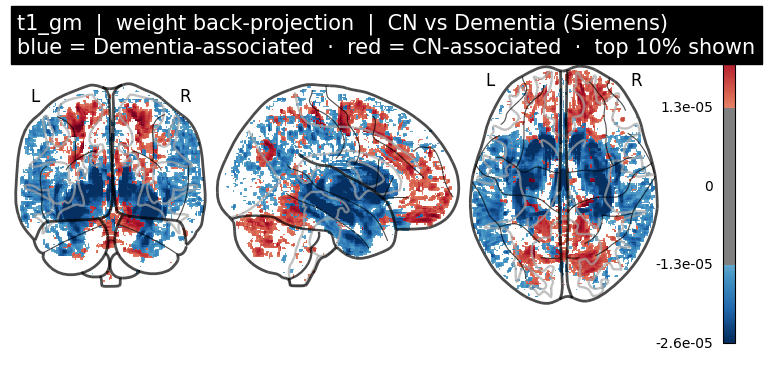

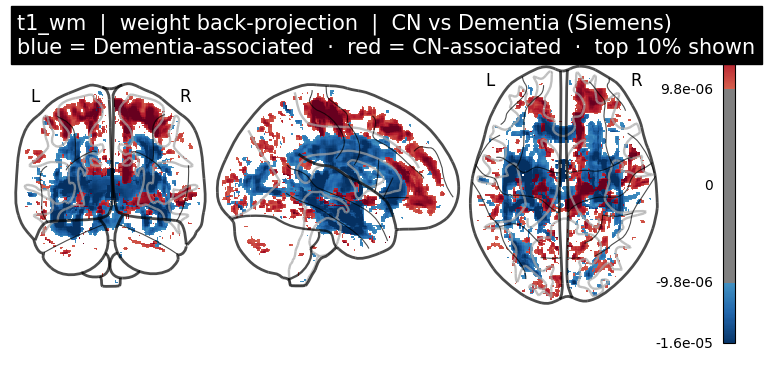

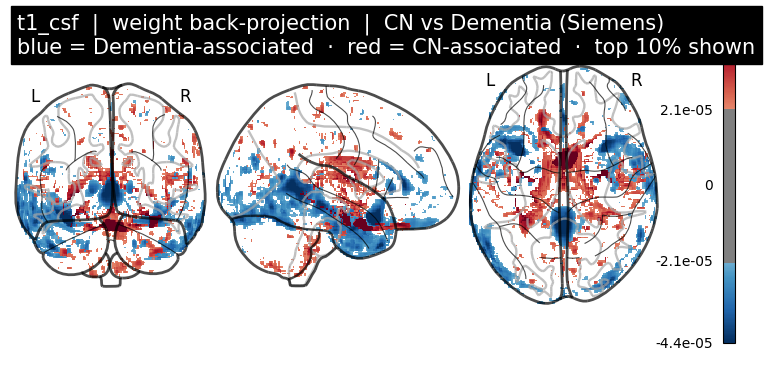

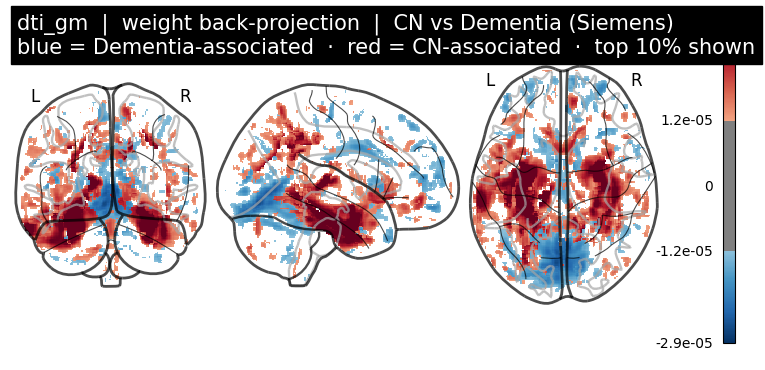

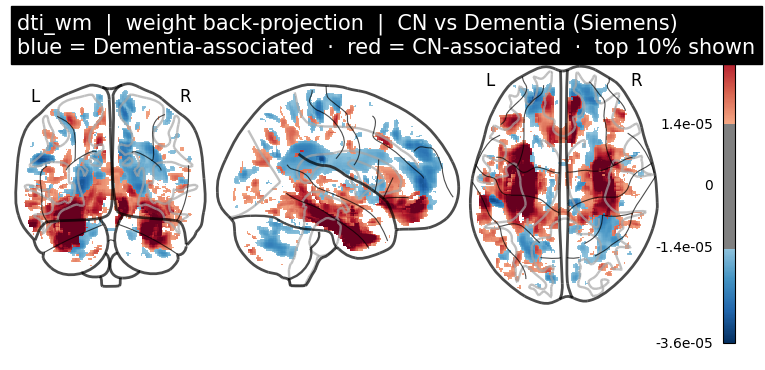

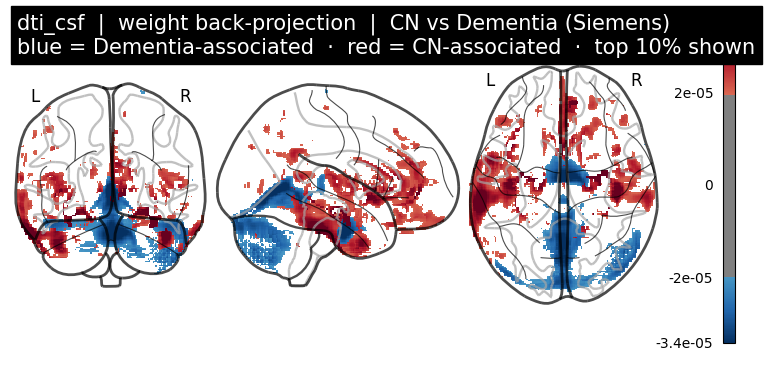

In [54]:
# ── Per-modality brain maps: weight back-projection and z-scored activation ───
# One standalone figure per modality for both map types.
# Negative weight = less tissue in Dementia (atrophy); positive = more in Dementia.
# z-score threshold 1.96 = consistent signal across all 5 folds.

FUSION_MODS = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]
mask_for = {"t1_gm": gm_mask, "t1_wm": wm_mask, "t1_csf": csf_mask,
            "dti_gm": gm_mask, "dti_wm": wm_mask, "dti_csf": csf_mask}

print("Value ranges (weight maps):")
for mod in FUSION_MODS:
    img  = nib.load(f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.nii.gz")
    data = img.get_fdata()
    nz   = np.abs(data[data != 0])
    print(f"  {mod:<10}  95th%={np.percentile(nz,95):.5f}  "
          f"99.5th%={np.percentile(nz,99.5):.5f}")
print()

# ── Weight maps (one figure each) ────────────────────────────────────────────
for mod in FUSION_MODS:
    img  = nib.load(f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.nii.gz")
    data = img.get_fdata()
    nz   = np.abs(data[data != 0])
    thr  = float(np.percentile(nz, 90))
    vmax = float(np.percentile(nz, 99.5))

    display = nlp.plot_glass_brain(
        img,
        colorbar=True,
        plot_abs=False,
        threshold=thr,
        vmax=vmax,
        title=f"{mod}  |  weight back-projection  |  CN vs Dementia (Siemens)\n"
              f"blue = Dementia-associated  ·  red = CN-associated  ·  top 10% shown",
        cmap="RdBu_r",
    )
    plt.savefig(f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.png",
                dpi=150, bbox_inches="tight")
    plt.show()